In [1]:
import pandas as pd
import numpy as np

In [9]:
df1=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df1

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [10]:
df1.isna().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [11]:
df1['Age'].fillna(df1['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [12]:
X = df1.iloc[:,1:3]
y = df1.iloc[:,0]

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

<Figure size 1300x500 with 0 Axes>

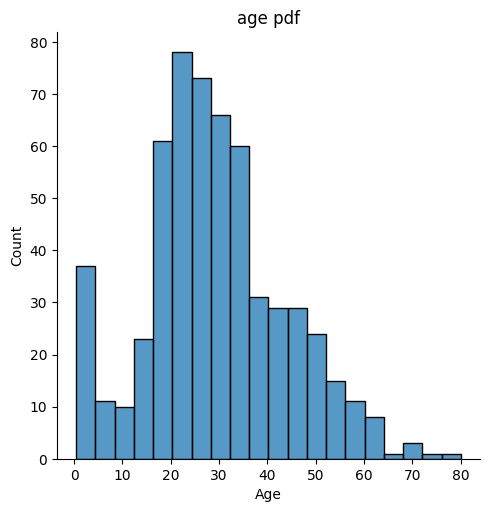

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy import stats


plt.figure(figsize=(13,5))
sns.displot(X_train['Age'])
plt.title('age pdf')

plt.show()

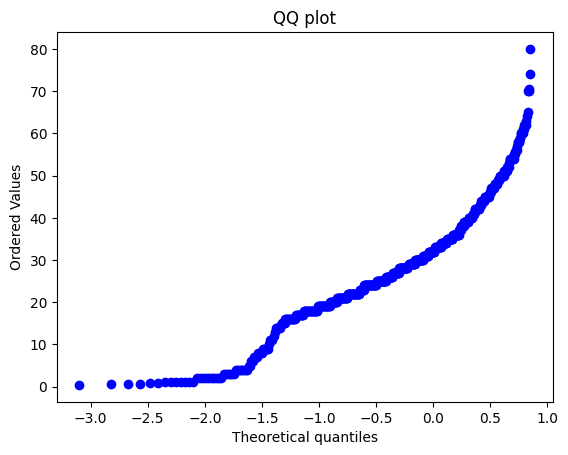

In [26]:

stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('QQ plot')
plt.show()

<Figure size 1300x500 with 0 Axes>

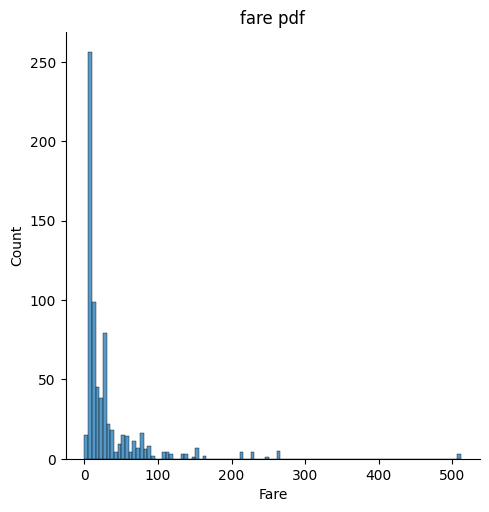

In [25]:

plt.figure(figsize=(13,5))
sns.displot(X_train['Fare'])
plt.title('fare pdf')

plt.show()

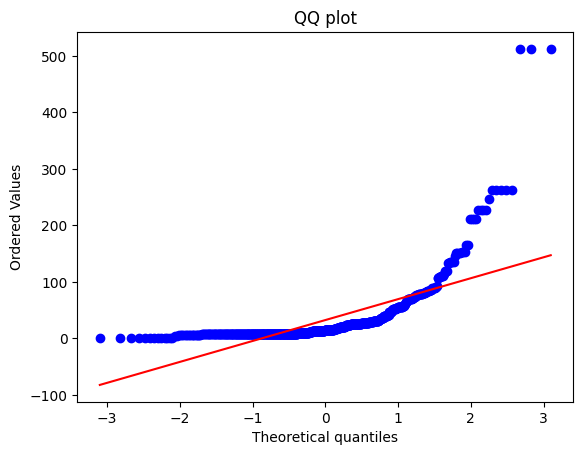

In [24]:
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('QQ plot')
plt.show()

In [30]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.impute import SimpleImputer

In [31]:
trf1 = FunctionTransformer(func=np.log1p)
X_train_trf = trf1.fit_transform(X_train)
X_test_trf = trf1.fit_transform(X_test)

In [33]:
df2 = pd.read_csv('concrete_data.csv')
df2

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [34]:
df2.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from scipy.stats import stats

In [36]:
df2.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [37]:
X = df2.drop(columns=['Strength'])
y = df2['Strength']

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [43]:
import matplotlib.pyplot as plt
import scipy.stats as stats

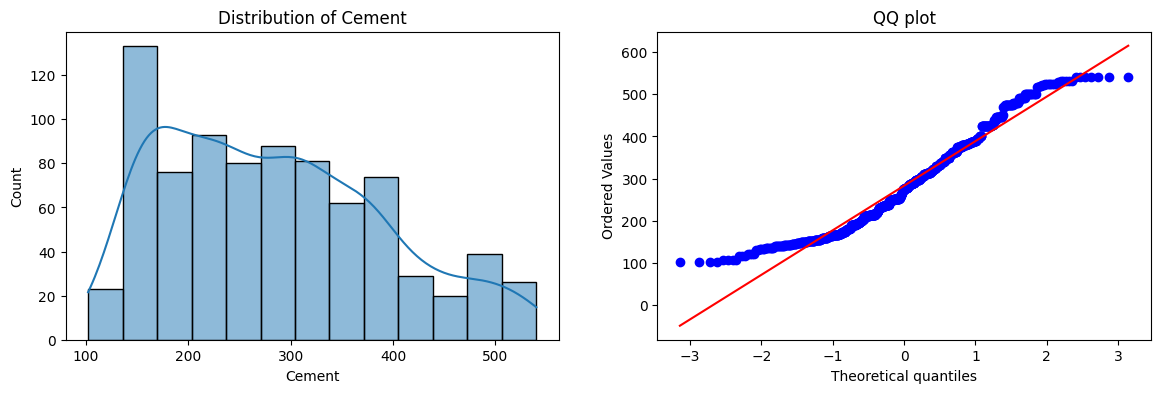

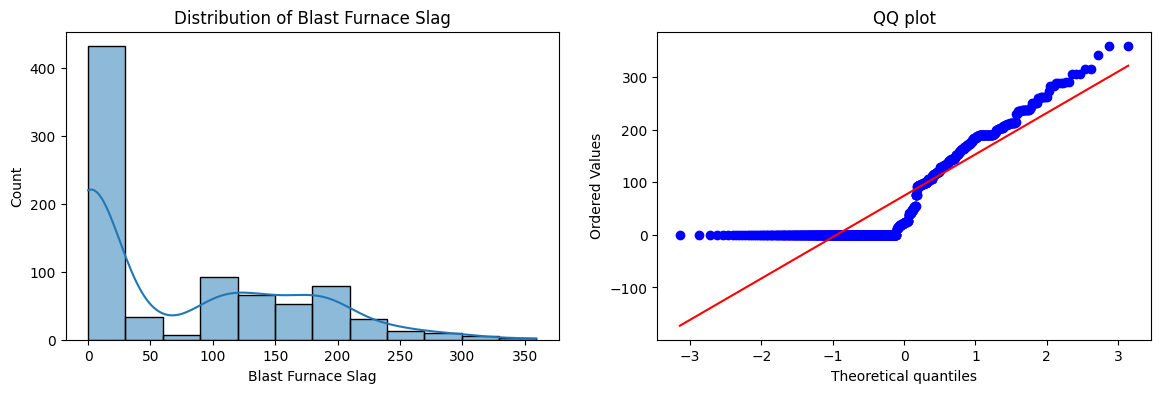

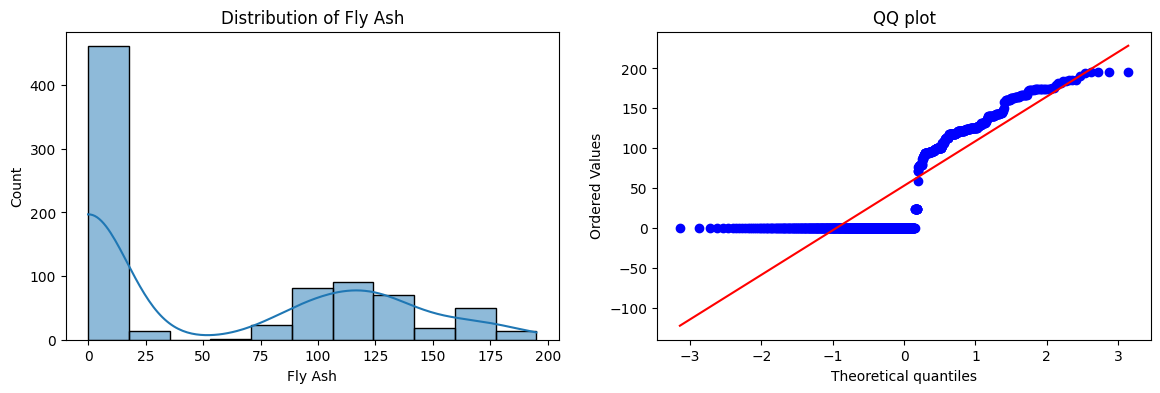

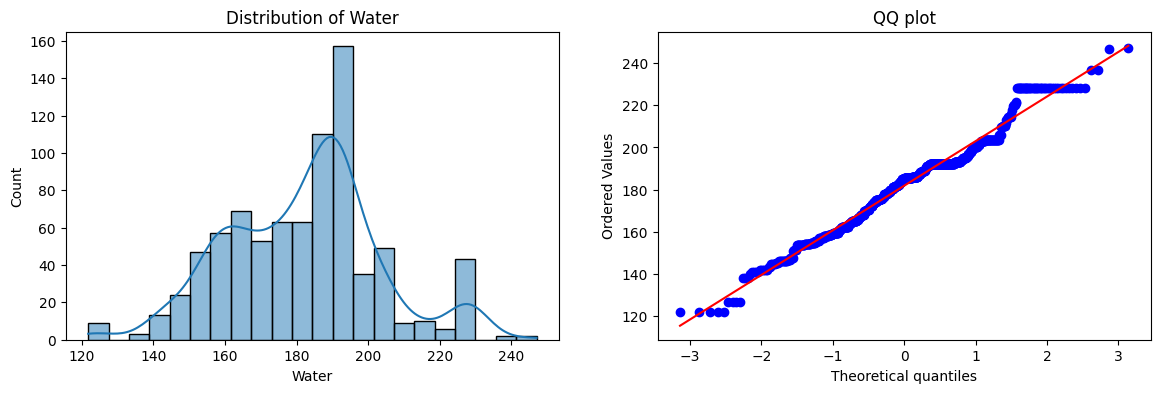

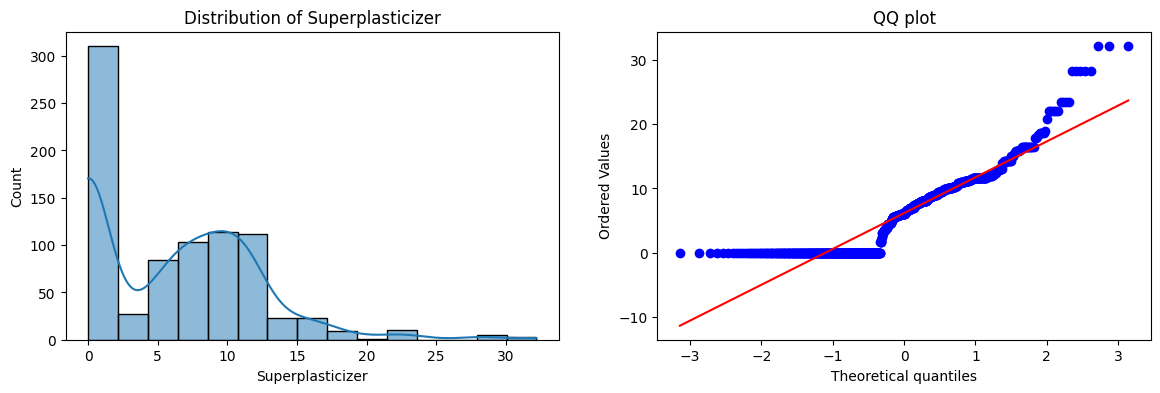

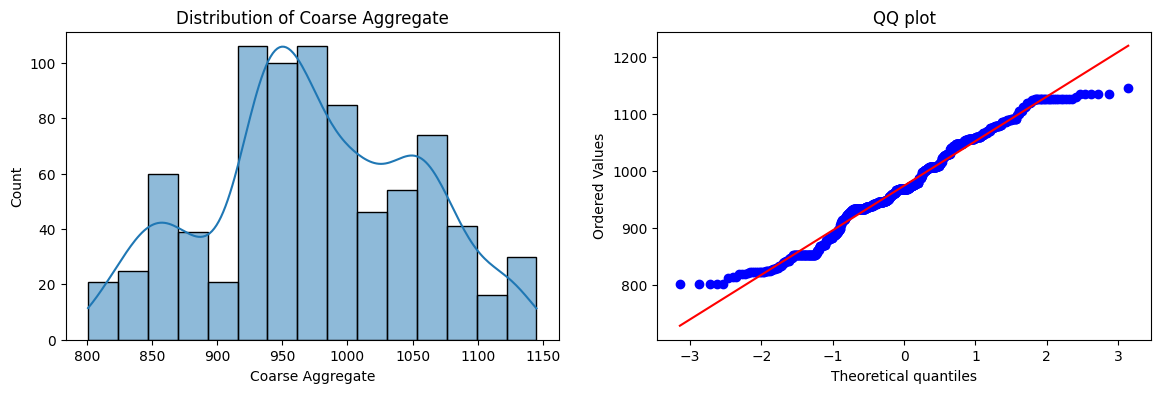

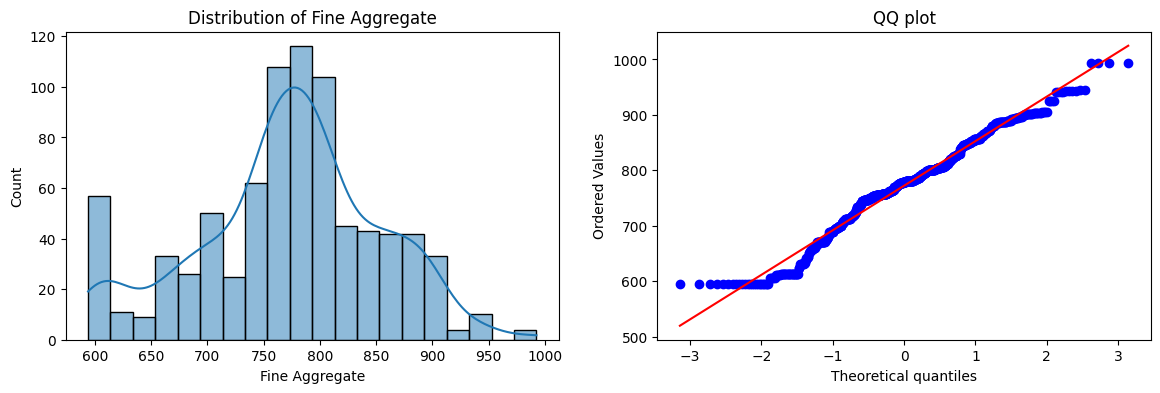

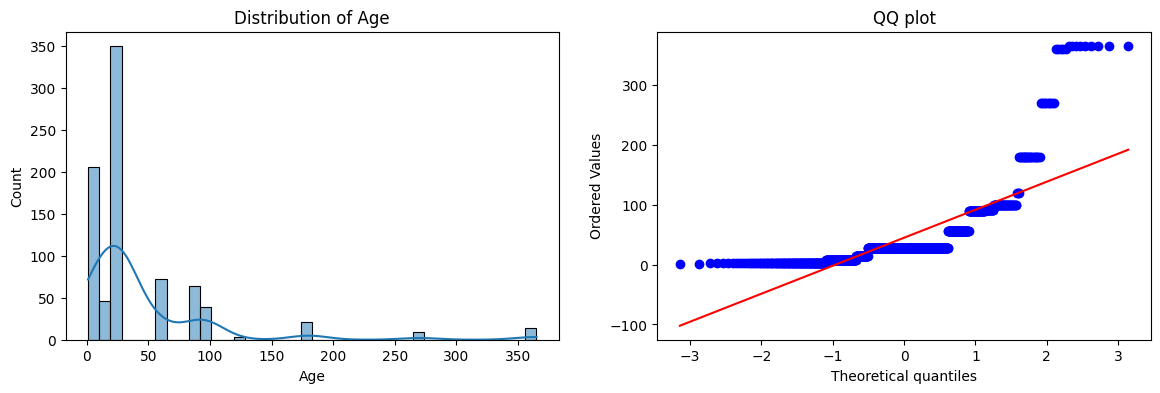

In [45]:
for col in X_train.columns:
    plt.figure(figsize=(14, 4))
    
    # Distribution Plot
    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col], kde=True)  # Changed from sns.displot to sns.histplot
    plt.title(f'Distribution of {col}')
    
    # QQ Plot
    plt.subplot(1, 2, 2)
    stats.probplot(X_train[col], dist='norm', plot=plt)
    plt.title('QQ plot')
    
    plt.show()
        

In [46]:
pt = PowerTransformer('box-cox')

X_train_trans = pt.fit_transform(X_train+0.000001)
X_test_trans = pt.fit_transform(X_test+0.000001)
pd.DataFrame({'cols':X_train.columns,'box_cox lambdas':pt.lambdas_})

,cols,box_cox lambdas
0,Cement,0.215602
1,Blast Furnace Slag,0.025996
2,Fly Ash,-0.006544
3,Water,0.959062
4,Superplasticizer,0.103365
5,Coarse Aggregate,1.192492
6,Fine Aggregate,1.973781
7,Age,-0.014692


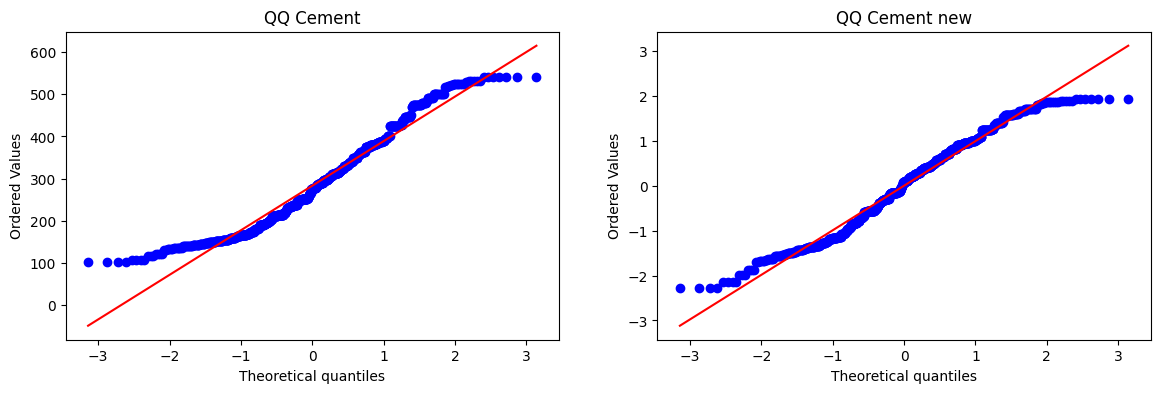

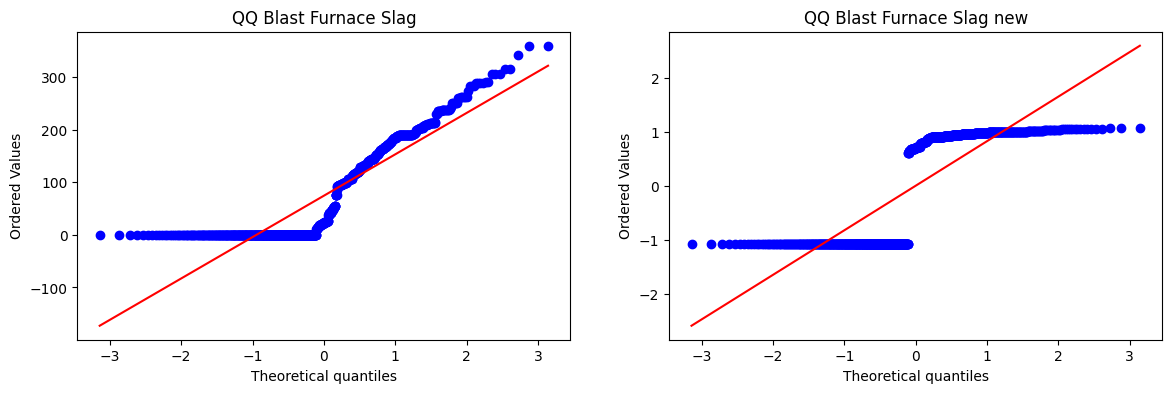

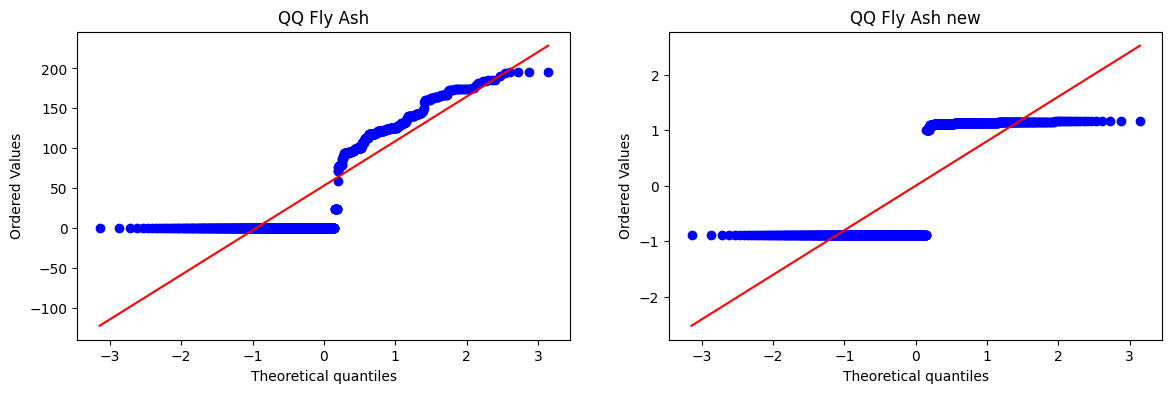

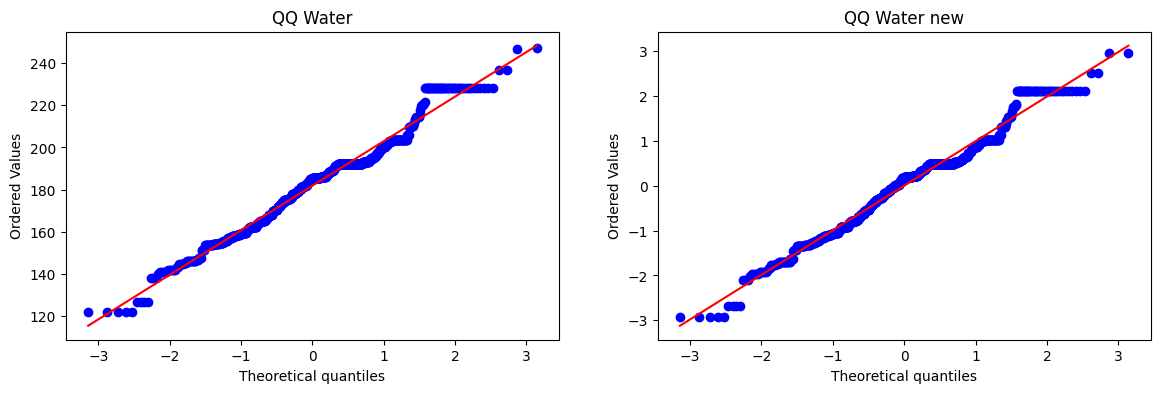

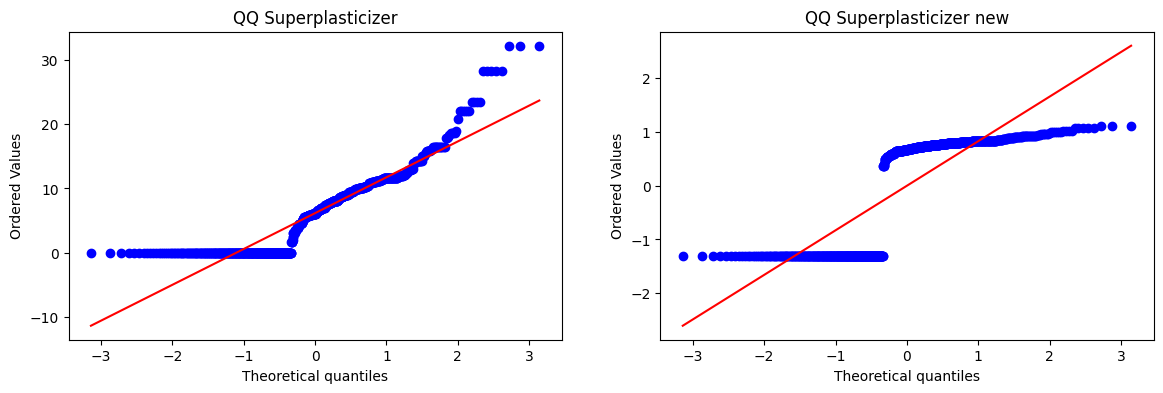

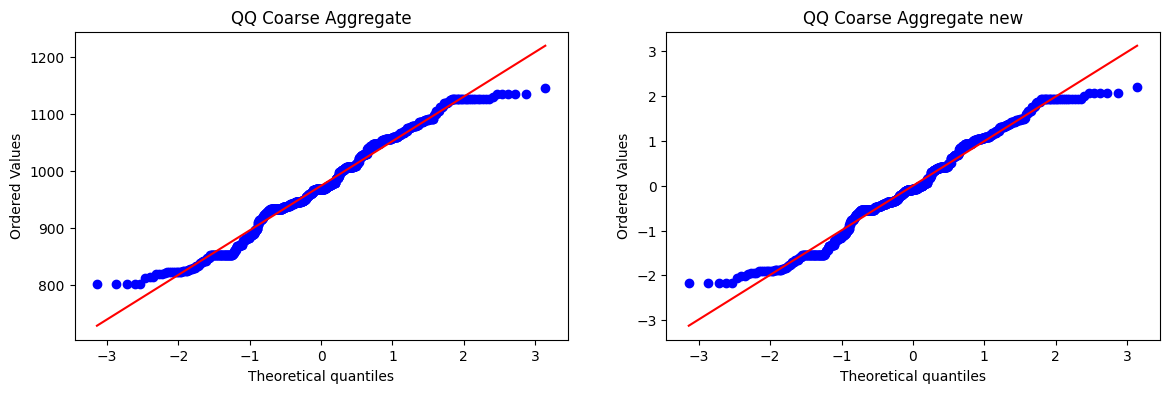

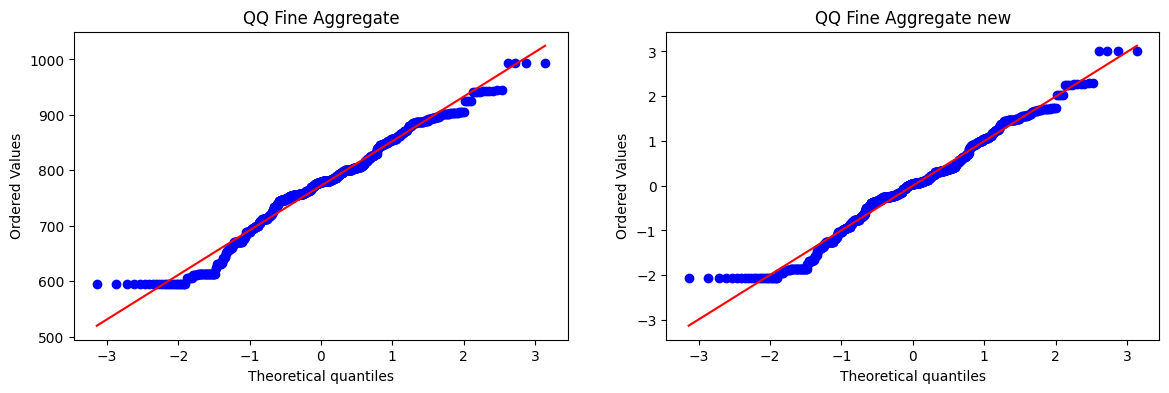

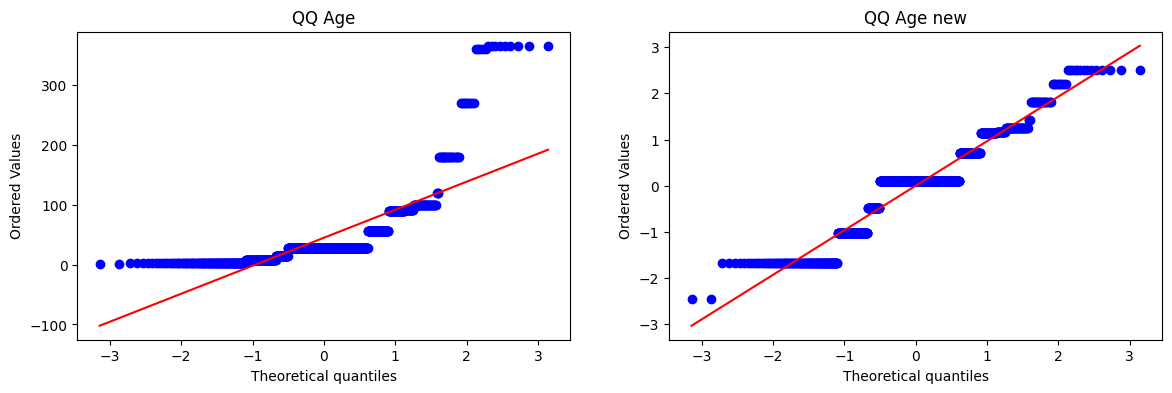

In [50]:
X_train_trans = pd.DataFrame(X_train_trans,columns=X_train.columns)
for col in X_train_trans.columns:
    plt.figure(figsize=(14, 4))
    
    # Distribution Plot
    plt.subplot(1, 2, 1)
    stats.probplot(X_train[col], dist='norm',plot=plt)  # Changed from sns.displot to sns.histplot
    plt.title(f'QQ {col}')
    
    # QQ Plot
    plt.subplot(1, 2, 2)
    stats.probplot(X_train_trans[col], dist='norm', plot=plt)
    plt.title(f'QQ {col} new')
    
    plt.show()

In [51]:
from sklearn.preprocessing import KBinsDiscretizer

In [53]:
df3 = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df3

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [54]:
df3.dropna()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
885,0,39.0,29.1250
886,0,27.0,13.0000
887,1,19.0,30.0000
889,1,26.0,30.0000


In [79]:
df3['Age'].fillna(df3['Age'].mean(),inplace=True)

In [80]:
df3.isna().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [81]:
X1 = df3.iloc[:,1:]
y1 = df3.iloc[:,0]

In [82]:
X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1,test_size=0.2,random_state=42)

In [83]:
kbin_age = KBinsDiscretizer(n_bins=10,strategy='quantile',encode='ordinal')
kbin_fare = KBinsDiscretizer(n_bins=10,strategy='quantile',encode='ordinal')

In [92]:
trf11 = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])


In [93]:
X_train_trf11 = trf11.fit_transform(X1_train)
X_test_trf11 = trf11.fit_transform(X1_test)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [90]:
trf11.named_transformers_['first'].bin_edges_

array([array([ 0.83      , 16.        , 20.        , 24.        , 29.        ,
              29.69911765, 34.        , 38.4       , 47.2       , 71.        ])],
      dtype=object)

In [91]:
trf11.named_transformers_['first'].n_bins_

array([9])

In [95]:
output = pd.DataFrame({
    'age':X1_train['Age'],
    'age_trf11':X_train_trf11[:,0],
    'fare':X1_train['Fare'],
    'fare_trf11':X_train_trf11[:,1]
})

In [97]:
output['age_label'] = pd.cut(x=X1_train['Age'],bins = trf11.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_label'] = pd.cut(x=X1_train['Fare'],bins=trf11.named_transformers_['second'].bin_edges_[0].tolist())

In [98]:
output.sample(10)

,age,age_trf11,fare,fare_trf11,age_label,fare_label
130,33.000000,6.0,7.8958,2.0,"(29.699, 34.0]","(7.854, 8.05]"
105,28.000000,4.0,7.8958,2.0,"(24.0, 29.0]","(7.854, 8.05]"
583,36.000000,6.0,40.1250,8.0,"(34.0, 38.4]","(39.515, 78.02]"
460,48.000000,8.0,26.5500,7.0,"(47.2, 71.0]","(25.986, 29.075]"
237,8.000000,0.0,26.2500,6.0,"(0.83, 16.0]","(25.986, 29.075]"
698,49.000000,8.0,110.8833,9.0,"(47.2, 71.0]","(78.02, 262.375]"
601,29.699118,5.0,7.8958,2.0,"(29.0, 29.699]","(7.854, 8.05]"
314,43.000000,7.0,26.2500,6.0,"(38.4, 47.2]","(25.986, 29.075]"
721,17.000000,1.0,7.0542,0.0,"(16.0, 20.0]","(0.0, 7.55]"
400,39.000000,7.0,7.9250,2.0,"(38.4, 47.2]","(7.854, 8.05]"
